In [1]:
import sys
import os
import numpy as np
import torch
import matplotlib.pyplot as plt

# Add src to path
sys.path.append(os.path.join(os.getcwd(), "ForceSMIP"))

# Import our modules
from data_loader import ForceSMIPDataLoader, yearly_average, compute_yearly_average_dict
from preprocessing import (
    merge_training_data, reshape_training_data, 
    apply_notnan_filter_complete
)
from algorithms import WeightedRidgeRegression, ridge_regression, LowRankSolver
from evaluation import ForceSMIPEvaluator, compute_trends_from_data, compute_statistics
from visualization import ForceSMIPVisualizer
from forcesmip_pipeline import ForceSMIPPipeline

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

print("Modules loaded successfully!")


Modules loaded successfully!


In [2]:
# Initialize pipeline
base_path = '/net/krypton/climdyn_nobackup/FTP'

# variable names: pr, prmax, psl, tas, tos, tasmax, tasmin, zmta
variable = 'tas'  # Sea surface temperature

pipeline = ForceSMIPPipeline(base_path, variable=variable)
print(f"Pipeline initialized for variable: {variable}")

Pipeline initialized for variable: tas


In [ ]:
# Initialize data loader
data_loader = ForceSMIPDataLoader(base_path)

# Load training data
print("Loading training data...")
dic_data, dic_forced_response, longitude, latitude = data_loader.load_training_data(variable)

print(f"Training data loaded:")
print(f"  Number of models: {len(dic_data)}")
print(f"  Model names: {list(dic_data.keys())}")
print(f"  Grid shape: {latitude.shape[0]} x {longitude.shape[0]}")
print(f"  Time steps: {list(dic_data.values())[0].shape[1]}")

Loading training data...
Processing 1/5: CESM2
  Processing 1/50: tas_mon_CESM2_historical_ssp370_r1251.013i1p1f1.188001-210012.nc
  Processing 2/50: tas_mon_CESM2_historical_ssp370_r1011.001i1p1f1.188001-210012.nc
  Processing 3/50: tas_mon_CESM2_historical_ssp370_r1251.015i1p1f1.188001-210012.nc
  Processing 4/50: tas_mon_CESM2_historical_ssp370_r1031.002i1p1f1.188001-210012.nc
  Processing 5/50: tas_mon_CESM2_historical_ssp370_r1251.014i1p1f1.188001-210012.nc
  Processing 6/50: tas_mon_CESM2_historical_ssp370_r1051.003i1p1f1.188001-210012.nc
  Processing 7/50: tas_mon_CESM2_historical_ssp370_r1251.016i1p1f1.188001-210012.nc
  Processing 8/50: tas_mon_CESM2_historical_ssp370_r1071.004i1p1f1.188001-210012.nc
  Processing 9/50: tas_mon_CESM2_historical_ssp370_r1251.017i1p1f1.188001-210012.nc
  Processing 10/50: tas_mon_CESM2_historical_ssp370_r1091.005i1p1f1.188001-210012.nc
  Processing 11/50: tas_mon_CESM2_historical_ssp370_r1251.018i1p1f1.188001-210012.nc
  Processing 12/50: tas_mon

In [ ]:
# Load test data
test_models = ['2A', '2B', '2C', '2D', '2E', '2F', '2G', '2H', '2I', '2J', '2K', '2L', '2M', '2N', '2O', '2P', '2Q', '2R', '2S', '2T', '2U']
print("\nLoading test data...")
data_test = data_loader.load_test_data(variable, tier='Tier2', test_models=test_models)


print(f"Test data shape: {data_test.shape}")


Loading test data...
Files in test data directory: ['tas_mon_2A.190001-202312.nc', 'tas_mon_2B.190001-202312.nc', 'tas_mon_2C.190001-202312.nc', 'tas_mon_2D.190001-202312.nc', 'tas_mon_2E.190001-202312.nc', 'tas_mon_2F.190001-202312.nc', 'tas_mon_2G.190001-202312.nc', 'tas_mon_2H.190001-202312.nc', 'tas_mon_2I.190001-202312.nc', 'tas_mon_2J.190001-202312.nc', 'tas_mon_2K.190001-202312.nc', 'tas_mon_2L.190001-202312.nc', 'tas_mon_2M.190001-202312.nc', 'tas_mon_2N.190001-202312.nc', 'tas_mon_2O.190001-202312.nc', 'tas_mon_2P.190001-202312.nc', 'tas_mon_2Q.190001-202312.nc', 'tas_mon_2R.190001-202312.nc', 'tas_mon_2S.190001-202312.nc', 'tas_mon_2T.190001-202312.nc', 'tas_mon_2U.190001-202312.nc']
Loading test data for 2A at index 0
create data_test array
Loading test data for 2B at index 1
Loading test data for 2C at index 2
Loading test data for 2D at index 3
Loading test data for 2E at index 4
Loading test data for 2F at index 5
Loading test data for 2G at index 6
Loading test data for

# Data processing

In [ ]:
# Compute yearly averages
print("Computing yearly averages...")
dic_data_yearly = compute_yearly_average_dict(dic_data)
dic_forced_response_yearly = compute_yearly_average_dict(dic_forced_response)

data_test_yearly = yearly_average(data_test)
# data_ground_truth_yearly = yearly_average(data_ground_truth)

print(f"Yearly data shape (first model): {list(dic_data_yearly.values())[0].shape}")
print(f"Test yearly shape: {data_test_yearly.shape}")

Computing yearly averages...
Yearly data shape (first model): (50, 221, 72, 144)
Test yearly shape: (21, 124, 72, 144)


In [ ]:
# Prepare training data for machine learning
print("Preparing training data...")

# Method 1: Merge all training data
x_train_merged, y_train_merged = merge_training_data(
    dic_data_yearly, dic_forced_response_yearly
)

# Method 2: Keep model separation
x_train_dict, y_train_dict = reshape_training_data(
    dic_data_yearly, dic_forced_response_yearly
)

print(f"Merged training data shape: X={x_train_merged.shape}, Y={y_train_merged.shape}")
print(f"Separated training data: {len(x_train_dict)} models")

Preparing training data...


Merged training data shape: X=torch.Size([40885, 10368]), Y=torch.Size([40885, 10368])
Separated training data: 5 models


# Capture the NaNs of the data

In [ ]:
def capture_nans(x_train_dict):
    """
    Capture indices of NaN values across all training data.
    Args:
        x_train_dict (dict): Dictionary of training data tensors with keys as model names.
    Returns:
        nan_union (list): List of indices where NaN values are found across all models.
        notnan_inter (list): List of indices where no NaN values are found across all models.
    """
    
    # enumerate in the dictionary and get the union of the nans for each pair ((key, value))
    for (key, value) in x_train_dict.items():
        nan_indices = list(torch.where(torch.abs(value[0,:,:]) > 1e9)[0].numpy())
        if 'nan_union' not in locals():
            nan_union = nan_indices
        else:
            nan_union = list(set(nan_union) | set(nan_indices))

    notnan_inter = list(set(range(value.shape[2])) - set(nan_union))

    return nan_union, notnan_inter

In [ ]:
nan_idx, notnan_idx =capture_nans(x_train_dict)

# Prepare test data for smoothing experiments
x_test = torch.from_numpy(data_test.reshape(
    data_test.shape[0], data_test.shape[1], -1
)).to(torch.float32)

print(f"Test data shape for smoothing: {x_test.shape}")

NameError: name 'x_train_dict' is not defined

In [ ]:
# add the nans that are also included in the test data
# record nan indices as the union of nans on each map
nan_idx_test = nan_idx.copy()

for idx_r in range(x_test.shape[0]):

    # get nan mask of test set 
    nan_mask = np.where(np.abs(x_test[idx_r,:,:])>1e10, True, False)

    # get the index of columns where there is at least one True in the nan mask
    col_indices = np.where(np.any(nan_mask, axis=0))[0]

    nan_idx_test = list(set(nan_idx_test) | set(col_indices))    

# define not nan indices (useful to ease the computations)
notnan_idx_test = list(set(list(range(x_test.shape[2]))) - set(nan_idx_test))
    

# replace the nan index by Nans
notnan_idx = notnan_idx_test
nan_idx = nan_idx_test

/tmp/ipykernel_2789/1696564261.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  nan_mask = np.where(np.abs(x_test[idx_r,:,:])>1e10, True, False)


In [ ]:
# Apply not-NaN filter to all data
x_train_merged_filtered, y_train_merged_filtered, \
x_train_dict_filtered, y_train_dict_filtered, x_test_filtered = apply_notnan_filter_complete(
    x_train_merged, y_train_merged,
    x_train_dict, y_train_dict,
    x_test, notnan_idx
)

              APPLYING NOT-NAN FILTER TO ALL DATA
Valid indices count: 6489

1. Filtering merged training data...
   X: torch.Size([40885, 10368]) -> torch.Size([40885, 6489])
   Y: torch.Size([40885, 10368]) -> torch.Size([40885, 6489])

2. Filtering training dictionaries...
Filtering training dictionaries...
Keeping 6489 valid spatial features
CESM2: X torch.Size([50, 221, 10368]) -> torch.Size([50, 221, 6489])
CanESM5: X torch.Size([25, 221, 10368]) -> torch.Size([25, 221, 6489])
MIROC-ES2L: X torch.Size([30, 221, 10368]) -> torch.Size([30, 221, 6489])
MIROC6: X torch.Size([50, 221, 10368]) -> torch.Size([50, 221, 6489])
MPI-ESM1-2-LR: X torch.Size([30, 221, 10368]) -> torch.Size([30, 221, 6489])

3. Filtering test data...
   Test: torch.Size([21, 1488, 10368]) -> torch.Size([21, 1488, 6489])

=== FILTERING SUMMARY ===
Original spatial features: 10368
Filtered spatial features: 6489
Features removed: 3879
Reduction: 37.4%


# Run the ridge regression model

In [ ]:
# Updated cell for model training
# Train global ridge regression model
lambda_reg = 2000.0
# print(f"Training ridge regression with lambda={lambda_reg}...")

w_ridge = ridge_regression(x_train_merged_filtered,y_train_merged_filtered, lambda_reg, verbose=True)
# print(f"Ridge weights shape: {w_ridge.shape}")

Solving ridge regression with λ=2000.0
Input shape: X=torch.Size([40885, 6489]), Y=torch.Size([40885, 6489])
Reshaped: X=torch.Size([40885, 6489]), Y=torch.Size([40885, 6489])
Ridge weights computed: torch.Size([6489, 6489])


In [ ]:
# Setup low-rank solver for efficient multiple rank solutions
print(f"\nSetting up low-rank solver...")
lr_solver = LowRankSolver()
lr_solver.fit(x_train_merged_filtered, y_train_merged_filtered, w_ridge, verbose=True)

# Get solutions for multiple ranks efficiently
ranks_to_test = [5, 10, 15, 20, 25, 30, 50]
rank_solutions = lr_solver.get_multiple_ranks(ranks_to_test, verbose=True)

# Print explained variance for different ranks
print(f"\nExplained variance by rank:")
cumulative_var = lr_solver.cumulative_variance_ratio()
for rank in ranks_to_test:
    if rank <= len(cumulative_var):
        print(f"  Rank {rank}: {cumulative_var[rank-1]:.4f}")

# Use the primary rank solution
primary_rank = 30
w_ridge_lr = rank_solutions[primary_rank]
print(f"Primary rank-{primary_rank} weights shape: {w_ridge_lr.shape}")


Setting up low-rank solver...
Computing SVD for low-rank approximations...
SVD computed: U=torch.Size([47374, 6489]), S=torch.Size([6489]), Vt=torch.Size([6489, 6489])
Singular values range: 0.000010 to 6702.369629
Computed solutions for ranks: [5, 10, 15, 20, 25, 30, 50]

Explained variance by rank:
  Rank 5: 0.9988
  Rank 10: 0.9998
  Rank 15: 0.9999
  Rank 20: 1.0000
  Rank 25: 1.0000
  Rank 30: 1.0000
  Rank 50: 1.0000
Primary rank-30 weights shape: torch.Size([6489, 6489])


### Smoothing

In [ ]:
# # do some smoothing
from preprocessing import moving_average_smoothing

x_test_smooth = moving_average_smoothing(x_test_filtered, window_size=12*20, mode='same')

In [ ]:
# display some time series 

import matplotlib.pyplot as plt

idx_grid_cell = 50  # Change this index to visualize different grid cells

for i in range(3):
    plt.figure(figsize=(12, 4))
    plt.plot(x_test_filtered[i,:,idx_grid_cell], label='Original', alpha=0.7)
    plt.plot(x_test_smooth[i,:,idx_grid_cell], label='Smoothed', alpha=0.7)
    plt.title(f'Time Series {i+1}')
    plt.xlabel('Time Steps')
    plt.ylabel('Value')
    plt.legend()
    plt.show()

In [ ]:
# Make predictions using different methods
print("Making predictions...")

# Global models
y_pred_ridge = x_test_filtered @ w_ridge
y_pred_ridge_lr = x_test_filtered @ w_ridge_lr

y_pred_ridge_smooth = x_test_smooth @ w_ridge
y_pred_ridge_lr_smooth = x_test_smooth @ w_ridge_lr

Making predictions...


In [ ]:
# Initialize evaluator
evaluator = ForceSMIPEvaluator()

# Convert predictions to yearly averages and compute trends
def to_yearly_and_trends(pred_data, trend_years=slice(30, None)):
    """Helper function to convert monthly to yearly and compute trends."""
    pred_numpy = pred_data.cpu().numpy() if isinstance(pred_data, torch.Tensor) else pred_data
    pred_yearly = pred_numpy.reshape(pred_numpy.shape[0], pred_numpy.shape[1] // 12, 12, pred_numpy.shape[2])
    pred_yearly = pred_yearly.mean(axis=2)
    return compute_trends_from_data(pred_yearly, trend_years)

# Compute trends for all predictions
trend_years = slice(0, None)  # Last 43 years for trend computation


# trends_ground_truth = compute_trends_from_data(data_ground_truth_yearly, trend_years)
trends_ridge = to_yearly_and_trends(y_pred_ridge, trend_years)
trends_ridge_smooth = to_yearly_and_trends(y_pred_ridge_smooth, trend_years)
trends_ridge_lr = to_yearly_and_trends(y_pred_ridge_lr, trend_years)
trends_ridge_lr_smooth = to_yearly_and_trends(y_pred_ridge_lr_smooth, trend_years)


print(f"Trend shape: {trends_ridge.shape}")

Trend shape: (21, 7616)


# Visualization

In [ ]:
# Initialize visualizer
visualizer = ForceSMIPVisualizer(longitude, latitude, test_models)

# reshape the trends for visualization
trends_ridge_fullmap = np.zeros((trends_ridge.shape[0], x_test.shape[2]), dtype=np.float32)
trends_ridge_fullmap[:,notnan_idx] = trends_ridge
trends_ridge_fullmap[:,nan_idx] = np.nan  # Fill NaNs for visualization

# reshape the trends for visualization
trends_ridge_smooth_fullmap = np.zeros((trends_ridge.shape[0], x_test.shape[2]), dtype=np.float32)
trends_ridge_smooth_fullmap[:,notnan_idx] = trends_ridge_smooth
trends_ridge_smooth_fullmap[:,nan_idx] = np.nan  # Fill NaNs for visualization


trends_ridge_lr_fullmap = np.zeros((trends_ridge_lr.shape[0], x_test.shape[2]), dtype=np.float32)
trends_ridge_lr_fullmap[:,notnan_idx] = trends_ridge_lr
trends_ridge_lr_fullmap[:,nan_idx] = np.nan  # Fill NaNs for visualization

trends_ridge_lr_smooth_fullmap = np.zeros((trends_ridge_lr.shape[0], x_test.shape[2]), dtype=np.float32)
trends_ridge_lr_smooth_fullmap[:,notnan_idx] = trends_ridge_lr_smooth
trends_ridge_lr_smooth_fullmap[:,nan_idx] = np.nan


Using vmin=-8782781844815872.0, vmax=8782781844815872.0 for colorbar


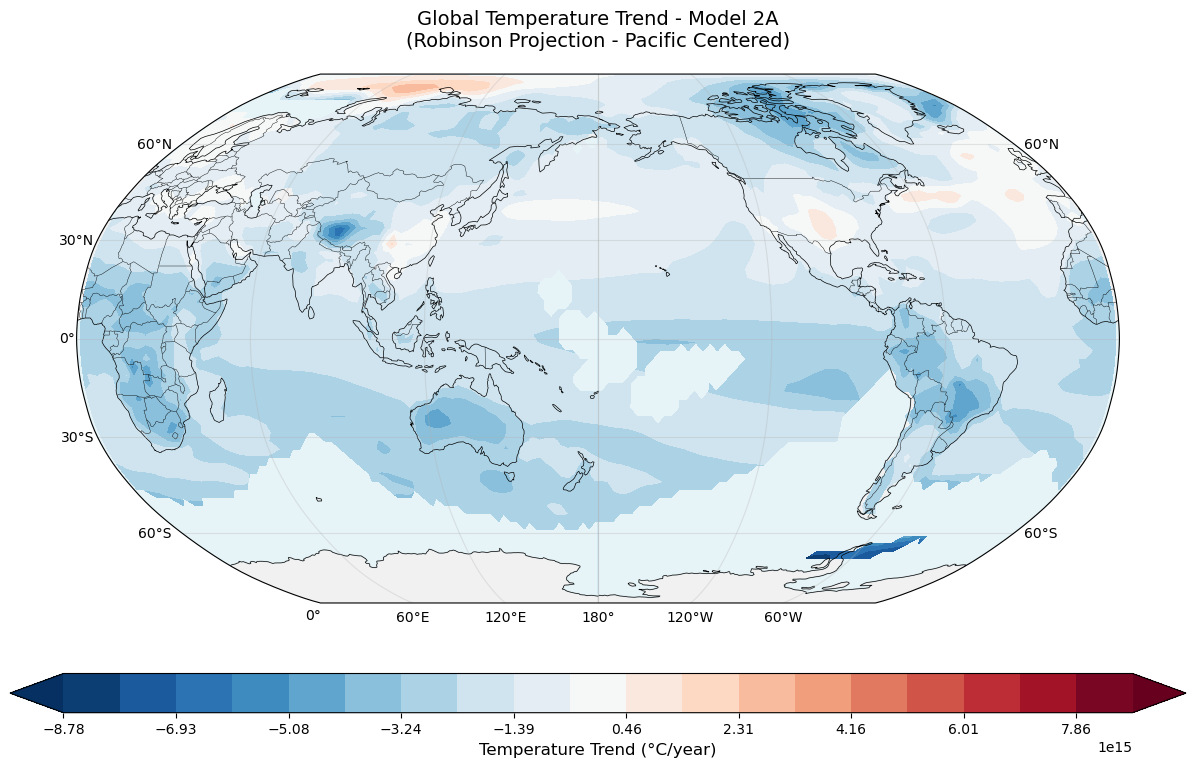

In [ ]:
# display the trend map for the first test model
for idx_run in range(trends_ridge_smooth_fullmap.shape[0]):
    fig = visualizer.plot_robinson_projection(trends_ridge_smooth_fullmap, 
                                    title="Global Temperature Trend",
                                    cmap='RdBu_r',
                                    run_idx=idx_run,
                                    central_longitude=180)

## Cross validation to select the best combination (ridge penalty param, rank)

In [ ]:
## 6.5 Cross-Validation to get the best Lambda Optimization

print("="*70)
print("         CROSS-VALIDATION LAMBDA OPTIMIZATION")
print("="*70)

# Import the cross-validation function
from algorithms import cross_validation_lambda_optimization, cross_validation_lambda_rank_optimization,\
                        plot_cv_lambda_results, plot_cv_lambda_rank_results

# Define lambda values to test (broader range for better optimization)
lambda_values_cv = [10.0, 100.0, 500.0, 1000.0, 2500.0, 5000.0, 7500.0, 10000.0]
lambda_values_cv = [100.0]

print("Performing cross-validation to optimize lambda for worst-case performance...")

# Optimize lambda using cross-validation with worst-case objective


cv_optimization = cross_validation_lambda_optimization(
    x_train_dict_filtered, y_train_dict_filtered,
    lambda_values=lambda_values_cv,
    cv_folds=5,
    objective='worst_case',  # Optimize for worst-case NRMSE
    verbose=True
)


In [ ]:
## 6.5 Cross-Validation Lambda Optimization

print("="*70)
print("         CROSS-VALIDATION LAMBDA OPTIMIZATION")
print("="*70)

# Import the cross-validation function
from algorithms import cross_validation_lambda_optimization, cross_validation_lambda_rank_optimization,\
                        plot_cv_lambda_results, plot_cv_lambda_rank_results

# Define lambda values to test (broader range for better optimization)
lambda_values_cv = [100.0, 500.0, 1000.0, 2500.0, 5000.0, 7500.0, 10000.0]
rank_values_cv = [5, 10, 15, 20, 25, 30, 50, 100]

print("Performing cross-validation to optimize lambda for worst-case performance...")

# Optimize lambda using cross-validation with worst-case objective


cv_optimization = cross_validation_lambda_optimization(
    x_train_dict_filtered, y_train_dict_filtered,
    lambda_values=lambda_values_cv,
    cv_folds=5,
    objective='worst_case',  # Optimize for worst-case NRMSE
    verbose=True
)



# cv_optimization = cross_validation_lambda_rank_optimization(
#     x_train_dict_filtered, y_train_dict_filtered,
#     lambda_values=lambda_values_cv,
#     rank_values=rank_values_cv,
#     cv_folds=5,
#     objective='worst_case',  # Optimize for worst-case NRMSE
#     verbose=True
# )

# # Plot cross-validation results
# fig_cv = plot_cv_lambda_results(cv_optimization, figsize=(18, 5))
# plt.show()

# Extract optimal lambda
optimal_lambda_cv = cv_optimization['best_lambda']
print(f"\n🎯 OPTIMAL LAMBDA (CV-optimized): {optimal_lambda_cv}")
print(f"   Worst-case NRMSE: {cv_optimization['cv_results'][optimal_lambda_cv]['worst_nrmse']:.4f}")
print(f"   Mean NRMSE: {cv_optimization['cv_results'][optimal_lambda_cv]['mean_nrmse']:.4f}")